In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os; import sys
import numpy as np
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
# MPC import
from Deliverable_5_1.LinearMPC.MPCVelControl import MPCVelControl
from PIControl.PIControl import PIControl

from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [3]:
Ts = 0.05
sim_time = 10; H = 5.0
x0 = np.array([0, 0, 0, 0, 0, 0, 5, 5, 10, 0, 0, 1])  # initial state
x_target = np.zeros((12,))

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

# Static mass change and zero fuel rate
rocket.mass = 1.5
rocket.fuel_rate = 0.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(mpc, sim_time, H, x0, x_target=x_target, method='nonlinear')

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, Ref=ref[:,:-1], T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol); 


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
Simulating time 0.40: 
Simulating time 0.45: 
Simulating time 0.50: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.55: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.60: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.65: 
 State beta violation: -0.18 < -0.17, 
 State alpha violatio

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

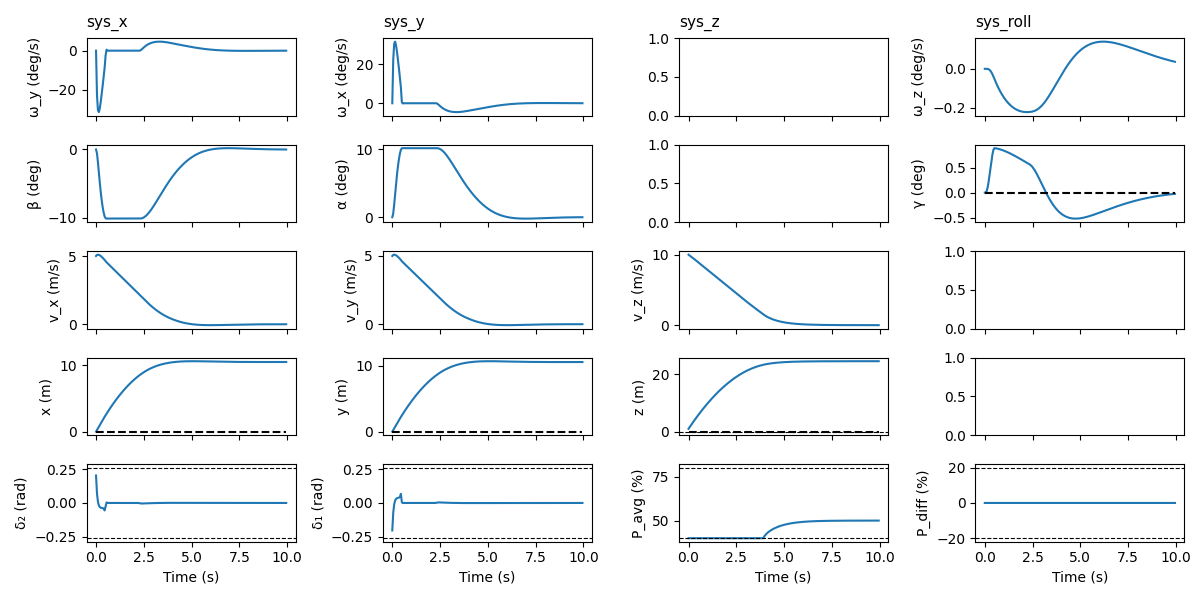

In [4]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, ref[:,:-1])

(200,)


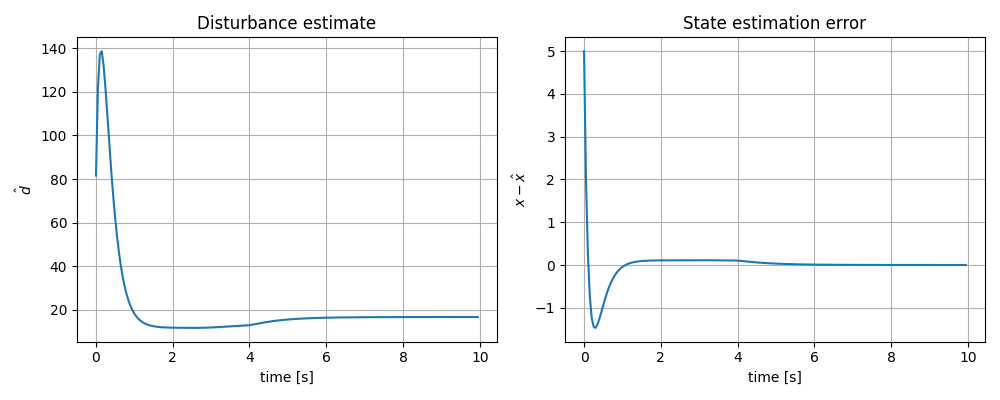

In [5]:
import matplotlib.pyplot  as plt
d_hat = np.array(mpc.mpc_z.d_hat_hist).squeeze()
print(d_hat.shape)
x_err = np.array(mpc.mpc_z.x_err_hist).squeeze()

Ts = 0.05
t = np.arange(len(d_hat)) * Ts

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, d_hat)
plt.xlabel("time [s]")
plt.ylabel(r"$\hat d$")
plt.title("Disturbance estimate")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, x_err)
plt.xlabel("time [s]")
plt.ylabel(r"$x - \hat x$")
plt.title("State estimation error")
plt.grid(True)

plt.tight_layout()
plt.show()


(200,)
0.007354499999999999


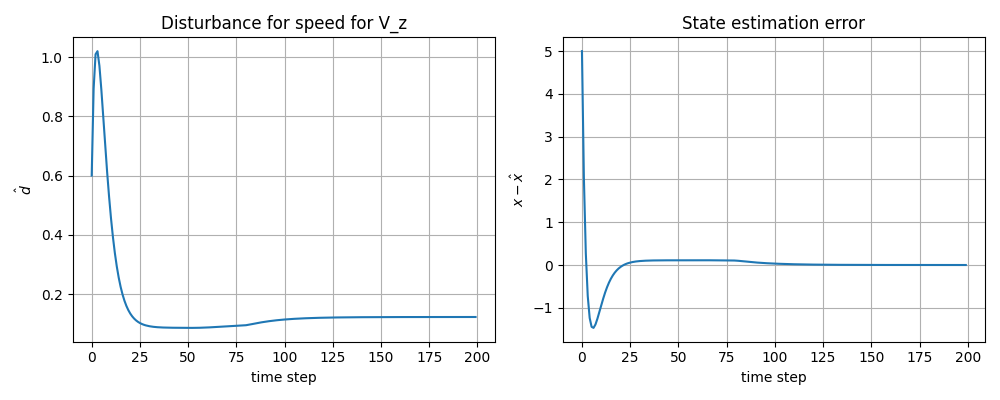

In [6]:
print(d_hat.shape)
print(mpc.mpc_z.Bd[0,0])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(mpc.mpc_z.Bd[0,0] * d_hat)
plt.xlabel("time step")
plt.ylabel(r"$\hat d$")
plt.title("Disturbance for speed for V_z")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x_err)
plt.xlabel("time step")
plt.ylabel(r"$x - \hat x$")
plt.title("State estimation error")
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
d_hat[-1]* mpc.mpc_z.Bd[0,0]


np.float64(0.12255668917358692)

In [8]:
print(x_err[-1])

7.226703168790034e-05


In [9]:
# MPC import
from Deliverable_4_1.LinearMPC_part_4.MPCVelControl import MPCVelControl
from PIControl.PIControl import PIControl

from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [10]:
Ts = 0.05
sim_time = 20
H = 5.0
x0 = np.array([0, 0, 0, 0, 0, 0, 5, 5, 10, 0, 0, 1])  # initial state
pos_target = np.array([0, 0, 0])



rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
pos_controller = PIControl(pos_target)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

rocket.mass = 1.5
rocket.fuel_rate = 0.0

t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(
    mpc, sim_time, H, x0, pos_control=pos_controller, method="nonlinear"
)

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(
    t_cl[:-1],
    x_cl[:, :-1],
    u_cl,
    Ref=ref[:, :-1],
    T_ol=t_ol[..., :-1],
    X_ol=x_ol,
    U_ol=u_ol,
);

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
Simulating time 0.40: 
Simulating time 0.45: 
Simulating time 0.50: 
Simulating time 0.55: 
Simulating time 0.60: 
Simulating time 0.65: 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
Simulating time 0.85: 
Simulating time 0.90: 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.95: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 1.00: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 1.05: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 1.10: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 1.15: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 1.20: 
 S

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=399, step=2), IntSlider(value=0…

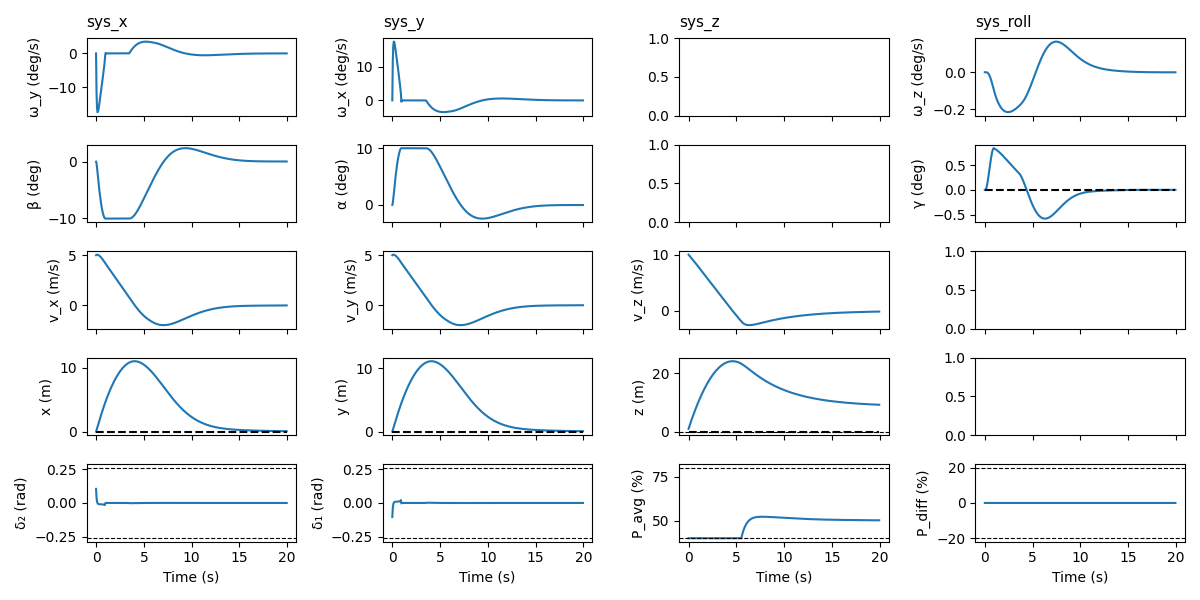

In [11]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, ref[:,:-1])

In [12]:
print("time",t_cl[-1], "Speed V_x",x_cl[8, -1])
print("There is a offset of 1.73m/s")

print("v_z trajectory:", x_cl[8, :])


time 20.00000000000015 Speed V_x -0.13145094481470523
There is a offset of 1.73m/s
v_z trajectory: [10.          9.89779756  9.79941289  9.70127714  9.60257375  9.50307443
  9.4026767   9.30131122  9.19892646  9.09548457  8.99097585  8.88541005
  8.77881459  8.67123019  8.56272658  8.45338908  8.34330568  8.23256333
  8.12119685  8.0086468   7.89831773  7.78844797  7.67848557  7.56851215
  7.45854011  7.3485678   7.23859554  7.12862326  7.018651    6.90867873
  6.79870646  6.68873419  6.57876192  6.46878965  6.35881738  6.24884512
  6.13887284  6.02890058  5.91892831  5.80895604  5.69898377  5.5890115
  5.47903924  5.36906697  5.2590947   5.14912243  5.03915016  4.9291779
  4.81920563  4.70923336  4.59926109  4.48928882  4.37931656  4.26934429
  4.15937202  4.04939975  3.93942749  3.82945522  3.71948295  3.60951068
  3.49953841  3.38956615  3.27959388  3.16962161  3.05964934  2.94967708
  2.83970481  2.72973254  2.61976027  2.50977275  2.39971214  2.28955751
  2.17938962  2.06926495  1